# Wavefronts, optics, and propagators

A dLux optical model is a sequence of transformations of a sampled complex field.
This tutorial follows one `Wavefront` from a physical pupil to focal and defocused
planes, showing how optics change the field and propagators change its grid.

We will construct a wavefront, apply transmission and OPD, compare MFT and FFT
Fraunhofer propagation, introduce Fresnel, free-space, and ABCD propagation, and
finally inspect the intermediate states of an `OpticalSystem`.

In [1]:
import jax.numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm, PowerNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

import dLux as dl

%matplotlib inline
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.family": "serif",
        "image.cmap": "inferno",
        "image.origin": "lower",
    }
)

bad = (0.0, 0.0, 0.0, 0.5)
cmaps = {
    "intensity": mpl.colormaps["inferno"].with_extremes(bad=bad),
    "opd": mpl.colormaps["RdBu"].with_extremes(bad=bad),
    "residual": mpl.colormaps["seismic"].with_extremes(bad=bad),
    "phase": mpl.colormaps["twilight_shifted"].with_extremes(bad=bad),
}


def colorbar(image, label, size="5%", pad=0.05):
    ax = image.axes
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size=size, pad=pad)
    return ax.figure.colorbar(image, cax=cax, label=label)

## Construct and modify a wavefront

`GridSpec` stores physical sampling in `(x, y)` order, while arrays use `(y, x)`.
A scalar wavelength creates a monochromatic wavefront; an array of wavelengths adds
leading chromatic axes without requiring a manual `vmap`.

In [2]:
pupil_grid = dl.GridSpec(n=128, diam=1.0, unit="m")
wavefront = dl.Wavefront(650e-9, pupil_grid)
chromatic = dl.Wavefront(np.array([600e-9, 650e-9, 700e-9]), pupil_grid)

print(wavefront)
print("Monochromatic phasor:", wavefront.phasor.shape)
print("Chromatic phasor:", chromatic.phasor.shape)
print("Initial power:", wavefront.power)

Wavefront(
  grid=GridSpec(n=(128, 128), d=f32[2], c=None, unit='m'),
  phasor=c64[128,128],
  wavelength=f32[]
)
Monochromatic phasor: (128, 128)
Chromatic phasor: (3, 128, 128)
Initial power: 6.1035156e-05


An `Optic` combines amplitude transmission, physical OPD in metres, and an optional
phase in radians. OPD therefore produces a wavelength-dependent phase, whereas a
phase array is already dimensionless.

In [3]:
pupil_def = dl.SimpleCircular(
    diameter=0.9,
    secondary_diameter=0.25,
    spider_width=0.012,
    spider_angles=[0, 90],
    opd=dl.ZernikeDef(nolls=[4, 5, 6], norm=dl.Norm("rms", 40e-9)),
)
pupil = pupil_def(pupil_grid, coeffs=np.array([1.0, -0.5, 0.25]))
after_pupil = pupil(wavefront)

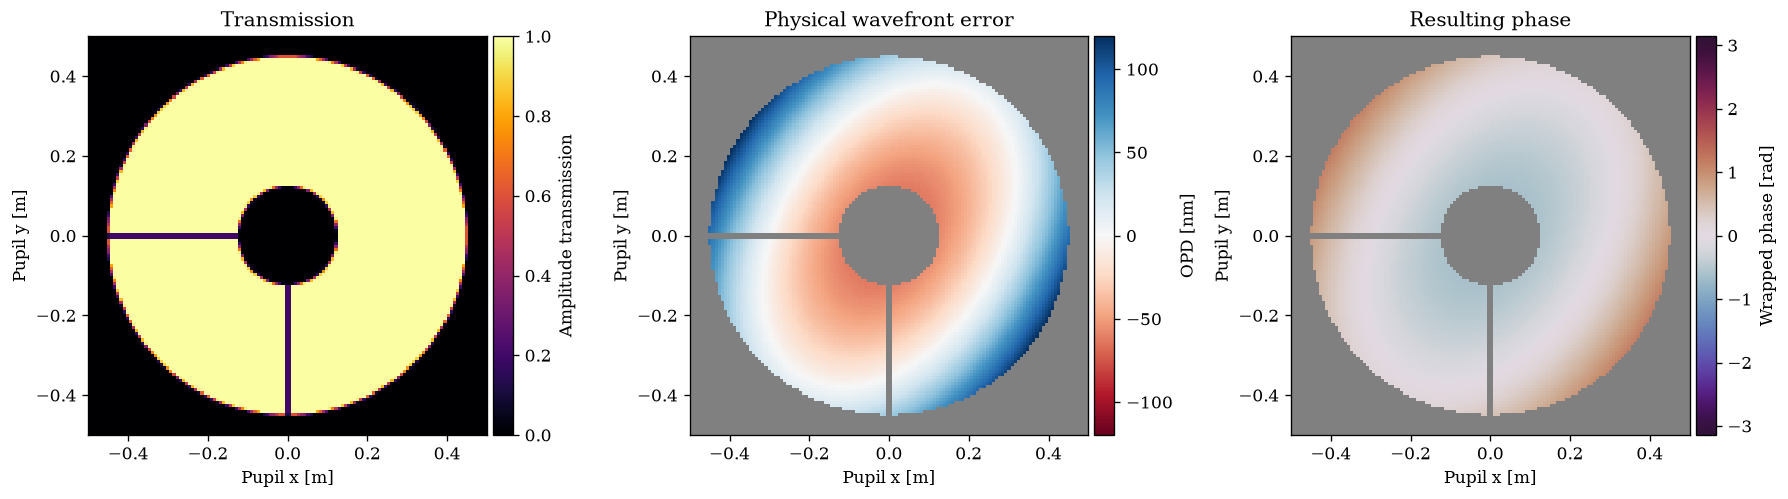

In [4]:
## COLLAPSE: Plotting code
extent = pupil_grid.extent(ndim=2, unit="m")
support = pupil.transmission > 0.5
opd = np.where(support, 1e9 * pupil.opd.evaluate(), np.nan)
phase = np.where(support, after_pupil.phase, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im = axes[0].imshow(pupil.transmission, cmaps["intensity"], extent=extent)
axes[0].set(title="Transmission", xlabel="Pupil x [m]", ylabel="Pupil y [m]")
colorbar(im, "Amplitude transmission")

im = axes[1].imshow(opd, cmaps["opd"], extent=extent, norm=CenteredNorm())
axes[1].set(title="Physical wavefront error", xlabel="Pupil x [m]", ylabel="Pupil y [m]")
colorbar(im, "OPD [nm]")

im = axes[2].imshow(phase, cmaps["phase"], extent=extent, vmin=-np.pi, vmax=np.pi)
axes[2].set(title="Resulting phase", xlabel="Pupil x [m]", ylabel="Pupil y [m]")
colorbar(im, "Wrapped phase [rad]")
fig.tight_layout()
plt.show()

## Propagate between pupil and focus

The MFT accepts the desired focal grid directly. The FFT instead fixes the output
sampling from the input grid and wavelength, while `ResizeSpec` controls padding and
cropping. MFT is therefore the usual choice for an explicitly sampled science image;
FFT is useful for native conjugate-plane transforms and round trips.

In [5]:
focal_grid = dl.GridSpec(n=96, d=15, unit="mas")
mft = dl.Fraunhofer(focal_grid)
focal_mft = mft(after_pupil)

fft = dl.Fraunhofer(dl.ResizeSpec(pad=2), method="fft")
focal_fft = fft(after_pupil)
backward = dl.Fraunhofer(
    dl.ResizeSpec(crop=2),
    method="fft",
    inverse=True,
)
round_trip = backward(focal_fft)

print("Requested MFT grid:", focal_mft.grid)
print("Realised FFT grid:", focal_fft.grid)
print("Round-trip grid:", round_trip.grid)

Requested MFT grid: GridSpec(n=(96, 96), d=f32[2], c=None, unit='mas')
Realised FFT grid: GridSpec(n=(256, 256), d=f32[2], c=f32[2], unit='rad')
Round-trip grid: GridSpec(n=(128, 128), d=f32[2], c=f32[2], unit='m')


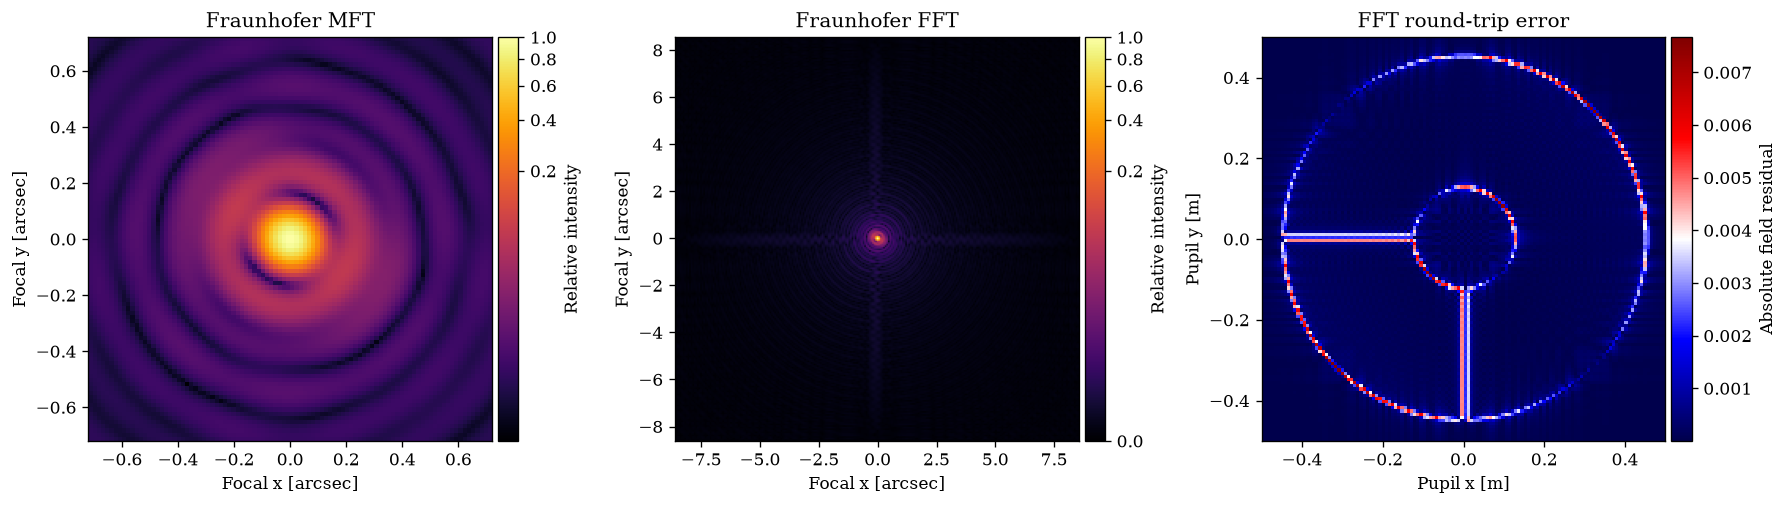

In [6]:
## COLLAPSE: Plotting code
mft_extent = focal_mft.grid.extent(ndim=2, unit="arcsec")
fft_extent = focal_fft.grid.extent(ndim=2, unit="arcsec")
residual = np.abs(round_trip.phasor - after_pupil.phasor)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im = axes[0].imshow(focal_mft.psf / focal_mft.psf.max(), cmaps["intensity"], extent=mft_extent, norm=PowerNorm(0.25))
axes[0].set(title="Fraunhofer MFT", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
colorbar(im, "Relative intensity")

im = axes[1].imshow(focal_fft.psf / focal_fft.psf.max(), cmaps["intensity"], extent=fft_extent, norm=PowerNorm(0.25))
axes[1].set(title="Fraunhofer FFT", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
colorbar(im, "Relative intensity")

im = axes[2].imshow(residual, cmaps["residual"], extent=extent)
axes[2].set(title="FFT round-trip error", xlabel="Pupil x [m]", ylabel="Pupil y [m]")
colorbar(im, "Absolute field residual")
fig.tight_layout()
plt.show()

## Fresnel, free-space, and ABCD propagation

`Fresnel` models a defocused focal surface. `FreeSpace` uses angular-spectrum
propagation between physical planes, with negative distance representing reverse
travel. `ABCDPropagator` composes paraxial elements and uses the resulting matrix as
the physical propagation definition; it deliberately has no generic inverse flag.

In [7]:
defocused = dl.Fresnel(focal_grid, defocus=2e-3)(after_pupil)

small_grid = dl.GridSpec(n=96, diam=4e-3, unit="m")
small_pupil = dl.SimpleCircular(2e-3)(small_grid)
near_field = dl.FreeSpace(0.05, dl.ResizeSpec(pad=2, crop=2))(
    small_pupil(dl.Wavefront(650e-9, small_grid))
)

relay_grid = dl.GridSpec(n=96, d=20e-6, unit="m")
relay = dl.ABCDPropagator(
    [dl.ABCDFreeSpace(0.2), dl.ABCDLens(0.2), dl.ABCDFreeSpace(0.2)],
    relay_grid,
)
relayed = relay(small_pupil(dl.Wavefront(650e-9, small_grid)))

print("Defocused focal grid:", defocused.grid)
print("Free-space grid:", near_field.grid)
print("Composed ABCD matrix:\n", relay.abcd)

Defocused focal grid: GridSpec(n=(96, 96), d=f32[2], c=None, unit='mas')
Free-space grid: GridSpec(n=(96, 96), d=f32[2], c=None, unit='m')
Composed ABCD matrix:
 [[-1.4901161e-08  2.0000000e-01]
 [-5.0000000e+00  0.0000000e+00]]


## Inspect a complete optical system

Named layers make both parameter paths and intermediate optical planes readable.
`debug_propagate_mono()` returns the wavefront after each layer, which is invaluable
when a complex model produces an unexpected final image.

In [8]:
optics = dl.OpticalSystem(
    grid=pupil_grid,
    layers=[
        ("pupil", pupil),
        ("focus", dl.Fraunhofer(focal_grid)),
    ],
)
output, states = optics.debug_propagate_mono(650e-9)

for name, state in states.items():
    print(f"{name:>8}: phasor={state.phasor.shape}, grid={state.grid}")

initial_wavefront: phasor=(128, 128), grid=GridSpec(n=(128, 128), d=f32[2], c=None, unit='m')
   pupil: phasor=(128, 128), grid=GridSpec(n=(128, 128), d=f32[2], c=None, unit='m')
   focus: phasor=(96, 96), grid=GridSpec(n=(96, 96), d=f32[2], c=None, unit='mas')


## Choosing a propagator

Use `Fraunhofer` for conjugate pupil/focal planes, `Fresnel` for deliberately
defocused focal surfaces, `FreeSpace` for physical near-field propagation, and
`ABCDPropagator` when an ordered paraxial ray matrix defines the system. Choose an
explicit `GridSpec` when output sampling is part of the model; choose `ResizeSpec`
when the FFT's native sampling is desired and only padding or cropping is needed.